### Ashim Sedhain
### MSCS-634-B01: Advanced Big Data and Data Mining
### Project Deliverable 2

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [25]:
df = pd.read_csv("./sample_data/salary_data.csv")

# This shows first 5 rows of the dataset

In [26]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# This describes the datatypes of each column in the dataframe

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


# This describes the dataframe: mean, standard deviation, min, max, 25%, 50%, and 75% percentile

In [28]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


# Handling Missing Values

In [29]:
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [30]:
df_clean = df.dropna()

I dropped the null rows due to their negligible impact on the dataset

# EDA

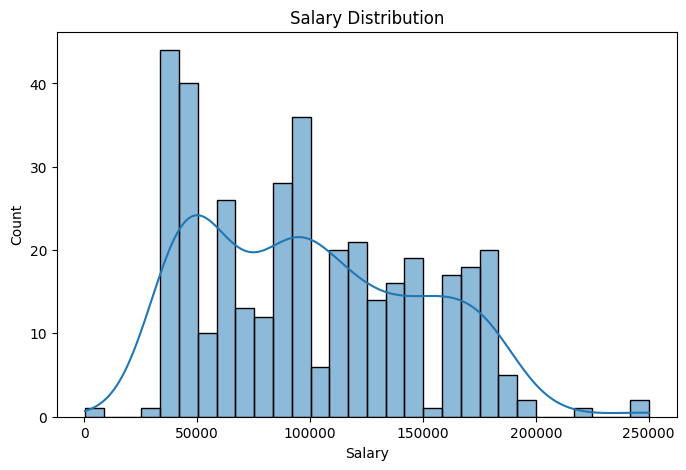

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Salary'], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

Histogram showing salary distribution

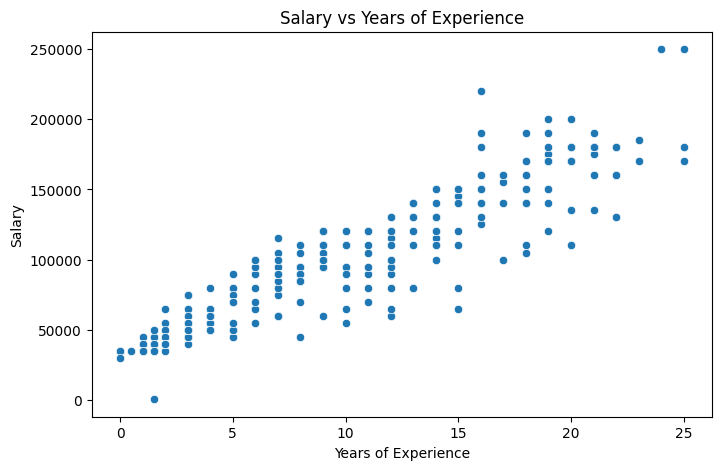

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Years of Experience', y='Salary', data=df_clean)
plt.title("Salary vs Years of Experience")
plt.show()

Scatter plot of salary and years of experience

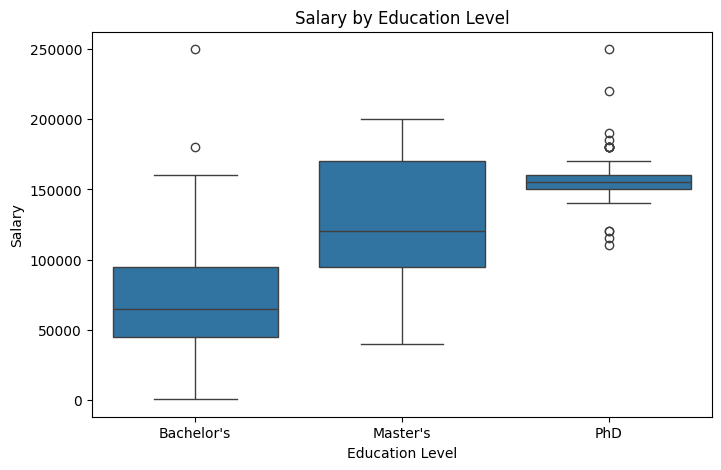

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education Level', y='Salary', data=df_clean)
plt.title("Salary by Education Level")
plt.show()

Box plot showing salary by education level

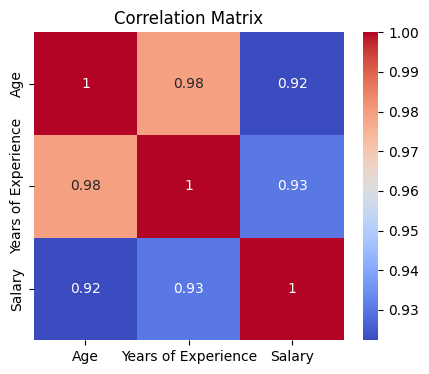

In [34]:
numeric_cols = ['Age', 'Years of Experience', 'Salary']
plt.figure(figsize=(5,4))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Correlation matrix between Salary, Years of Experience, and Age

# Deliverable 2 tasks start from Here

### Standardized the education level so that there is no Apostrophes

In [35]:
df_clean['Education Level'] = df_clean['Education Level'].str.replace("'", "", regex=False)

In [36]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

#### I used LabelEncoder for Gender because it’s a binary category and can be represented as 0 and 1. I used OrdinalEncoder for Education Level because the categories have a natural order (High School < Bachelor < Master < PhD). I used OneHotEncoder for Job Title since job titles have no meaningful order, and one-hot encoding prevents the model from interpreting them as ranked values.

In [37]:
le = LabelEncoder()
df_clean['Gender_Encoded'] = le.fit_transform(df_clean['Gender'])

# Ordinal Encoding for Education Level
edu_order = [[ 'Bachelors', 'Masters', 'PhD']]
oe = OrdinalEncoder(categories=edu_order)
df_clean['Education_Encoded'] = oe.fit_transform(df_clean[['Education Level']])

# One-Hot Encode Job Title
df_clean = pd.get_dummies(df_clean, columns=['Job Title'], drop_first=True)

# Created new feature
df_clean['Experience_Age_Ratio'] = df_clean['Years of Experience'] / df['Age']

# Seniority bins
df_clean['Seniority_Level'] = pd.cut(
    df_clean['Years of Experience'],
    bins=[0, 5, 10, 50],
    labels=['Junior', 'Mid', 'Senior']
)

df_clean = pd.get_dummies(df_clean, columns=['Seniority_Level'], drop_first=True)

df_clean.head()

,Age,Gender,Education Level,Years of Experience,Salary,Gender_Encoded,Education_Encoded,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,...,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer,Experience_Age_Ratio,Seniority_Level_Mid,Seniority_Level_Senior
0,32.0,Male,Bachelors,5.0,90000.0,1,0.0,False,False,False,...,False,False,False,False,False,False,False,0.156250,False,False
1,28.0,Female,Masters,3.0,65000.0,0,1.0,False,False,False,...,False,False,False,False,False,False,False,0.107143,False,False
2,45.0,Male,PhD,15.0,150000.0,1,2.0,False,False,False,...,False,False,False,False,False,False,False,0.333333,False,True
3,36.0,Female,Bachelors,7.0,60000.0,0,0.0,False,False,False,...,False,False,False,False,False,False,False,0.194444,True,False
4,52.0,Male,Masters,20.0,200000.0,1,1.0,False,False,False,...,False,False,False,False,False,False,False,0.384615,False,True


# Regression Modeling
### I imported the necessary libraries, selected features, split the dataset for train and test, fitted the models, and finally made predictions

In [39]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Selecting features
X = df_clean.drop(['Salary', 'Gender', 'Education Level'], axis=1)
y = df_clean['Salary']

# Spliting dataset for train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model selection
linear = LinearRegression()
lasso = Lasso(alpha=0.1)

# Fitting the models
linear.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Making predictions
y_pred_linear = linear.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

### Here, I am comparing the models and storing key metrics like R², MSE, RMSE in ***results*** object

In [40]:
results = {}

# Linear Regression Metrics
results['Linear Regression'] = {
    'R2': r2_score(y_test, y_pred_linear),
    'MSE': mean_squared_error(y_test, y_pred_linear),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_linear))
}

# Lasso Regression Metrics
results['Lasso Regression'] = {
    'R2': r2_score(y_test, y_pred_lasso),
    'MSE': mean_squared_error(y_test, y_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso))
}

results

{'Linear Regression': {'R2': 0.8246632445640929,
  'MSE': 420384287.7352564,
  'RMSE': np.float64(20503.27504900757)},
 'Lasso Regression': {'R2': 0.8270780784482579,
  'MSE': 414594524.9449627,
  'RMSE': np.float64(20361.594361566156)}}

In [41]:
cv_linear = cross_val_score(linear, X, y, cv=5, scoring='r2')
cv_lasso = cross_val_score(lasso, X, y, cv=5, scoring='r2')

print("Linear Regression CV R2:", cv_linear.mean())
print("Lasso Regression CV R2:", cv_lasso.mean())

Linear Regression CV R2: 0.8384537948441
Lasso Regression CV R2: 0.8407619317265533


### Visualizing R² and RMSE of the models

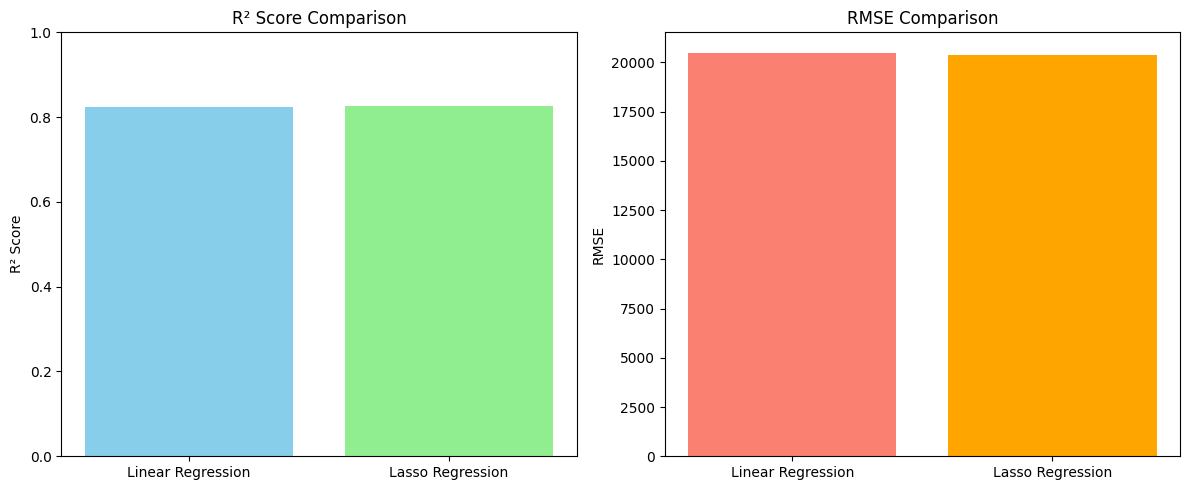

In [47]:
models = list(results.keys())
r2_scores = [results[m]['R2'] for m in models]
rmse_scores = [results[m]['RMSE'] for m in models]

x = np.arange(len(models))
width = 0.5

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# R² bar chart
axes[0].bar(models, r2_scores, color=['skyblue','lightgreen'])
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0,1)

# RMSE bar chart
axes[1].bar(models, rmse_scores, color=['salmon','orange'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

### Residual Plot of linear regression

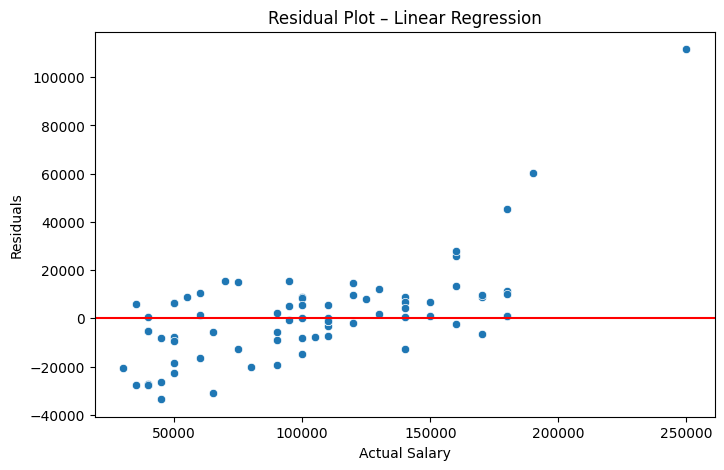

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=(y_test - y_pred_linear))
plt.axhline(0, color='red')
plt.xlabel("Actual Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot – Linear Regression")
plt.show()